# 01 Data understanding

**Purpose:** get to know every file before changing anything. This notebook only reads and describes the data. Cleaning happens in notebook 02, and labels are built in notebook 03.

**Inputs:** the raw data files in `data/raw/`.

**Outputs:** none. The findings here shape the decisions in the later notebooks, and they are summarised at the end.

**Questions this notebook answers**
1. What is in each file, and how do the files connect?
2. What does the delivery network look like (outlets, vehicles, depots)?
3. How do orders and route legs relate, and what period do train and test cover?
4. How often are deliveries late, and what seems to drive it?
5. How does weekly demand move, especially around festivals?
6. How tight is the Task 2B peak day?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora.io import load_raw
from xora.paths import DATA_RAW
from xora.timeutils import hhmm_to_minutes
from xora.plotting import apply_style, SERIES

apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

## 1. File inventory

The data zip has four folders. Here is every CSV with its size and shape.

In [2]:
inventory = []
for path in sorted(DATA_RAW.rglob("*.csv")):
    df = pd.read_csv(path)
    inventory.append({
        "folder": path.parent.name,
        "file": path.name,
        "rows": len(df),
        "columns": df.shape[1],
    })
pd.DataFrame(inventory)

,folder,file,rows,columns
0,General Data,calendar.csv,910,12
1,General Data,district_travel.csv,12,8
2,General Data,outlets.csv,120,9
3,General Data,road_conditions.csv,10920,3
4,General Data,service_allowance.csv,9,3
5,General Data,traffic_speed.csv,576,4
6,General Data,vehicles.csv,60,9
7,Submission Templates,submission_task1.csv,5014,3
8,Submission Templates,submission_task2a.csv,60,3
9,Submission Templates,submission_task2b.csv,85,6


In [3]:
orders = load_raw("deliveries_train.csv")
legs = load_raw("route_legs_train.csv")
orders_test = load_raw("task1_test_inputs.csv")
legs_test = load_raw("route_legs_test.csv")
outlets = load_raw("outlets.csv")
vehicles = load_raw("vehicles.csv")
calendar = load_raw("calendar.csv")
district_travel = load_raw("district_travel.csv")
allowance = load_raw("service_allowance.csv")
road = load_raw("road_conditions.csv")
traffic = load_raw("traffic_speed.csv")

**How the files connect**

- `deliveries_train.csv` has one row per order. Each dispatched order points to a route (`route_id`) and its position on that route (`seq_in_route`).
- `route_legs_train.csv` has one row per leg: a drive from the depot or the previous stop to the next outlet. It holds the actual times we need for labels.
- `outlets.csv`, `vehicles.csv`, `district_travel.csv` and `service_allowance.csv` describe the network and the current planning standards.
- `calendar.csv`, `road_conditions.csv` and `traffic_speed.csv` describe each day: paydays, festivals, monsoon, road disruption and traffic speed by hour.
- The test files mirror the train files but only carry planned times.

## 2. The delivery network

Three brands share one fleet. By design, Fresh delivers daily before 8 AM, Style weekly with seasonal peaks, and Tech as needed.

In [4]:
outlet_mix = outlets.pivot_table(index="brand", columns="depot", values="outlet_id", aggfunc="count", margins=True, margins_name="total")
outlet_mix

depot,Kandy,Peliyagoda,total
brand,,,
Fresh,31,49,80
Style,9,16,25
Tech,5,10,15
total,45,75,120


In [5]:
# Access constraints matter for both service time and Task 2B
pd.crosstab([outlets.brand, outlets.dock_type], outlets.parking_constraint)

parking_constraint  mall_dock  normal  van_only
brand dock_type                                
Fresh rear_dock             0      55         0
      street                0      14        11
Style mall_bay              9       0         0
      rear_dock             0       6         0
      street                0       9         1
Tech  mall_bay              3       0         0
      rear_dock             0       7         0
      street                0       4         1

In [6]:
fleet = vehicles.groupby(["depot", "type", "temp"]).agg(
    vehicles=("vehicle_id", "count"),
    volume_m3=("volume_cap_m3", "sum"),
    weight_kg=("weight_cap_kg", "sum"),
)
fleet

vehicles  volume_m3  weight_kg
depot      type  temp                                   
Kandy      truck ambient        13      362.0      66000
                 reefer          5      132.0      26990
           van   ambient         2       18.0       2400
                 reefer          2       14.0       2080
Peliyagoda truck ambient        27      788.0     145200
                 reefer          7      193.5      39140
           van   ambient         2       17.0       2300
                 reefer          2       14.0       2080

In [7]:
district_travel.merge(
    outlets.groupby("district").size().rename("outlets"), left_on="district", right_index=True
)[["district", "depot", "road_class", "outlets", "depot_to_district_km", "depot_to_district_freeflow_min", "inter_stop_freeflow_min"]]

,district,depot,road_class,outlets,depot_to_district_km,depot_to_district_freeflow_min,inter_stop_freeflow_min
0,Colombo,Peliyagoda,urban,24,12,24,8
1,Gampaha,Peliyagoda,suburban,15,28,37,9
2,Kalutara,Peliyagoda,suburban,10,48,64,12
3,Galle,Peliyagoda,highway,9,120,103,9
4,Matara,Peliyagoda,highway,6,160,137,10
5,Kurunegala,Peliyagoda,suburban,8,95,127,19
6,Puttalam,Peliyagoda,suburban,3,130,173,24
7,Kandy,Kandy,urban,20,8,16,6
8,Matale,Kandy,suburban,8,26,35,11
9,Nuwara Eliya,Kandy,hill,6,78,111,20


**What stands out**

- Fresh is two thirds of the outlets, so it will dominate both labels and demand.
- Only 16 of 60 vehicles can carry chilled goods, which hints that refrigeration is the scarce resource.
- Some districts are far from their depot (Puttalam is 173 free-flow minutes from Peliyagoda). Before 8 AM that leaves little room for more than one trip.

## 3. Orders and route legs

First, what period each set covers and what happened to each order.

In [8]:
period = pd.DataFrame({
    "first order": [orders.order_date.min(), orders_test.order_date.min()],
    "last order": [orders.order_date.max(), orders_test.order_date.max()],
    "orders": [len(orders), len(orders_test)],
    "route legs": [len(legs), len(legs_test)],
}, index=["train", "test"])
period

,first order,last order,orders,route legs
train,2024-01-01,2026-02-14,92307,91894
test,2026-02-16,2026-03-28,5014,5014


In [9]:
status = pd.concat({
    "train": orders.dispatch_status.value_counts(),
    "test": orders_test.dispatch_status.value_counts(),
}, axis=1).fillna(0).astype(int)
status

,train,test
dispatch_status,,
attempted,90351,4924
deferred,1543,90
not_run,413,0


In [10]:
pd.crosstab(orders.brand, orders.temp_requirement, margins=True)

temp_requirement,ambient,chilled,All
brand,,,
Fresh,52720,35135,87855
Style,2740,0,2740
Tech,1712,0,1712
All,57172,35135,92307


`attempted` orders went out on their order date. `deferred` orders were pushed to the next day. `not_run` orders were never dispatched, so they have no route. The test set has no `not_run` orders, which matters later for the Task 2A weekly totals.

Next, does every dispatched order have exactly one leg? We join on route and stop position.

In [11]:
dispatched = orders[orders.route_id.notna()].astype({"seq_in_route": int})
joined = dispatched.merge(
    legs, left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"],
    how="left", suffixes=("", "_leg"), indicator=True,
)
pd.Series({
    "dispatched orders": len(dispatched),
    "matched to a leg": (joined._merge == "both").sum(),
    "outlet agrees": (joined.outlet_id == joined.to_outlet).sum(),
    "leg date equals dispatch date": (joined.dispatch_date == joined.date).sum(),
})

dispatched orders                91894
matched to a leg                 91894
outlet agrees                    91894
leg date equals dispatch date    91894
dtype: int64

Every dispatched order, including deferred ones, matches exactly one leg, and the outlet and date agree in every case. So the leg is where each order's actual arrival and departure times live, and deferred orders can be used for training too.

Most Fresh outlets get two orders on the same day: one ambient and one chilled. They usually travel on different vehicles.

In [12]:
orders.groupby(["order_date", "outlet_id"]).size().value_counts().rename("outlet-days").rename_axis("orders per outlet per day")

orders per outlet per day
2    35135
1    22037
Name: outlet-days, dtype: int64

## 4. Lateness and timing: a first look

The formal labels come in notebook 03. Here we use the raw times to see the shape of the problem. An arrival counts as late when it is after the outlet's `window_close_time`.

In [13]:
j = joined.copy()
for col in ["planned_arrival_time", "arrival_time", "window_close_time", "planned_depart_time", "actual_depart_time"]:
    j[col + "_min"] = hhmm_to_minutes(j[col])

j["late"] = j.arrival_time_min > j.window_close_time_min
j["arrival_vs_plan_min"] = j.arrival_time_min - j.planned_arrival_time_min

pd.Series({
    "late rate": j.late.mean().round(3),
    "median minutes later than planned": j.arrival_vs_plan_min.median(),
    "mean minutes later than planned": j.arrival_vs_plan_min.mean().round(1),
    "Fresh arriving after 08:00": (j.loc[j.brand == "Fresh", "arrival_time_min"] > 480).mean().round(3),
})

late rate                             0.196
median minutes later than planned    35.000
mean minutes later than planned      52.600
Fresh arriving after 08:00            0.193
dtype: float64

In [14]:
j.groupby("brand").late.mean().round(3).rename("late rate").to_frame()

,late rate
brand,
Fresh,0.204
Style,0.055
Tech,0.025


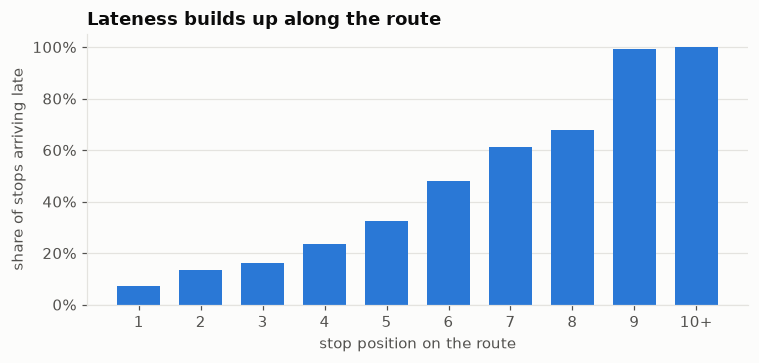

stop,1,2,3,4,5,6,7,8,9,10
mean,0.072,0.135,0.162,0.234,0.323,0.48,0.612,0.678,0.991,1.0
size,25198.000,21371.000,16222.000,12120.000,7464.000,5296.00,2527.000,1110.000,452.000,134.0


In [15]:
by_stop = j.assign(stop=(j.seq + 1).clip(upper=10)).groupby("stop").late.agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(by_stop.index, by_stop["mean"], color=SERIES[0], width=0.7)
ax.set_xticks(by_stop.index, [str(i) if i < 10 else "10+" for i in by_stop.index])
ax.set_xlabel("stop position on the route")
ax.set_ylabel("share of stops arriving late")
ax.set_title("Lateness builds up along the route")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()
by_stop.round(3).T

Lateness is cumulative: every delay at an earlier stop pushes back the later ones. This is the main reason Task 1 will simulate whole routes instead of scoring each stop in isolation.

What slows the trucks down? We compare actual with planned travel time, against monsoon and the daily road disruption index (100 means clear roads).

In [16]:
j = j.merge(road, on=["district", "date"], how="left")
j["travel_ratio"] = j.actual_travel_duration_min / j.planned_travel_duration_min.clip(lower=1)
j["disruption_band"] = pd.cut(j.disruption_index, [0, 60, 80, 95, 100], labels=["below 60", "60 to 80", "80 to 95", "95 to 100"])

pd.concat({
    "by monsoon": j.groupby("monsoon").travel_ratio.median(),
    "by road disruption": j.groupby("disruption_band", observed=True).travel_ratio.median(),
}).round(2).rename("median actual / planned travel").to_frame()

median actual / planned travel
by monsoon         0                                    1.36
                   1                                    1.73
by road disruption below 60                             2.95
                   60 to 80                             2.10
                   80 to 95                             1.60
                   95 to 100                            1.40

In [17]:
first_stop = j[j.seq == 0]
(first_stop.actual_depart_time_min - first_stop.planned_depart_time_min).describe().round(1).rename("depot departure delay (min)").to_frame().T

,count,mean,std,min,25%,50%,75%,max
depot departure delay (min),25198.0,7.7,6.0,0.0,4.0,6.0,10.0,63.0


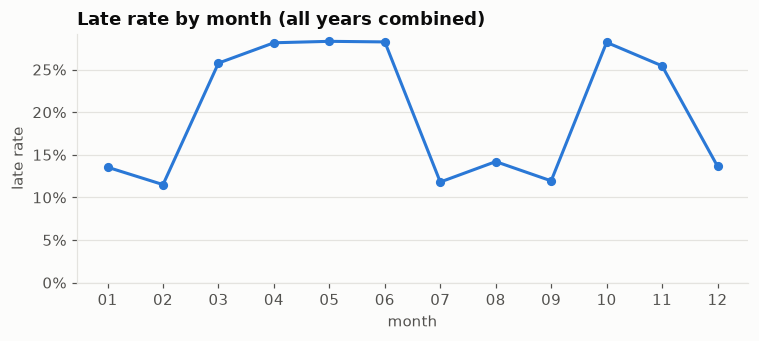

In [18]:
monthly = j.assign(month=j.date.str[5:7]).groupby("month").late.mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(monthly.index, monthly.values, color=SERIES[0], marker="o", markersize=5)
ax.set_ylim(0, None)
ax.set_xlabel("month")
ax.set_ylabel("late rate")
ax.set_title("Late rate by month (all years combined)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()

**What stands out**

- Trucks arrive well after their planned times, so today's plans are optimistic.
- Travel slows sharply in the monsoon and on disrupted days, and the trucks leave the depot late too.
- Late rates roughly double in the monsoon and festival months.

`road_conditions.csv` covers the test period as well, so disruption can be used as a feature. Notebook 04 checks whether a planner would actually know it at the 4 PM cutoff.